# Quantitative Medical Image Analysis with Python

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter1_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A hands-on course: from opening your first medical image file to measuring how much muscle and
fat a person has, from their CT scan.**

Every chapter builds one piece of that final measurement.

| Chapter | What you learn | Why the final measurement needs it |
|---|---|---|
| **1. Exploration** | Open a CT scan, read the information attached to it, understand what the numbers mean | You cannot measure anything until the numbers mean something |
| **2. Masks and filters** | Select the pixels you care about, and clean up the noise first | Fat and muscle are picked out by their brightness values |
| **3. Measurement** | Count, label and measure the regions you selected | Areas and averages *are* the body composition numbers |
| **4. Image comparison** | Compare scans from different people fairly | Two patients are different sizes, so raw numbers cannot be compared directly |
| **5. Body composition from CT** | Measure muscle and fat at the standard anatomical level | The destination |
| **6. Body composition from MR** | Do the same with MRI, which separates fat differently | The other way to do it, and why CT is still the usual choice |

### What is body composition, and why measure it?

Two people can weigh exactly the same and be in very different health. What matters is *what* the
weight is made of — muscle or fat, and where the fat sits. People with little muscle recover worse
from surgery, tolerate chemotherapy worse, and generally do worse than their weight alone predicts.

A CT scan already contains this information. It is a stack of cross-sections through the body, and
in each cross-section muscle and fat look different. If you can teach a computer to recognise and
count them, you get a measurement that a scale can never give you.

That is what this course builds, step by step.

### About the data

This repository contains **no medical images**. Each notebook downloads what it needs from the
public archive that hosts it, and prints where it came from. Nothing here is a mystery file of
unknown origin — you can always trace a number back to the scan it came from.

This chapter uses an abdominal CT scan from the **Pancreas-CT** collection at
[The Cancer Imaging Archive](https://www.cancerimagingarchive.net/). No account is needed.

---

# Chapter 1: Exploration

A medical image is two things at once: a grid of numbers, and a description of what those numbers
mean. Beginners see only the first, and that is where the mistakes come from.

By the end of this chapter you will be able to:

1. Download a real CT scan and load it as a 3D grid of numbers.
2. Read the information stored alongside the image, and explain why it is what makes measurement possible.
3. Convert the stored numbers into **Hounsfield units** — the scale that lets you tell fat from muscle.
4. Work out which way is up (this is less obvious than it sounds, and getting it wrong is common).
5. Turn a scan into a PyTorch tensor, ready for machine learning.
6. Look at a 3D scan from any direction, without distorting it.

## Setup

Run this cell first. On Google Colab it downloads the course files and installs what is missing.
On your own computer it just finds the project folder.

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", os.getcwd())

Running on Colab: False
Working directory: /home/wxc151/projects/Biomedical-Image-Analysis-in-Python


## 1. Getting a scan

The helper below downloads one patient's CT scan and remembers it, so you only wait once. It is
about 40 MB and takes roughly 20 seconds.

In [2]:
import medimage_data as md

ct_dir = md.fetch_pancreas_ct(0)

PANCREAS_0076: 210 slices in data/pancreas-ct/PANCREAS_0076
Source: Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). Data From Pancreas-CT. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU  (CC BY 3.0)


## 2. What is inside one file?

Medical images are stored in a format called **DICOM**. One DICOM file is one cross-section
("slice") through the body, and a whole scan is a folder full of them.

A DICOM file is not just a picture. Along with the pixels it stores a few hundred labelled facts:
how big each pixel is in millimetres, how far apart the slices are, what kind of scanner took it,
and so on. Those facts are called the **header**.

We read DICOM with a library called **pydicom**.

In [3]:
import pydicom

paths = sorted(ct_dir.glob("*.dcm"))
ds = pydicom.dcmread(paths[len(paths) // 2])     # a slice from the middle of the scan

print("Slices in this scan:", len(paths))
print("Pixels in one slice:", ds.pixel_array.shape)
print("Numbers stored as:  ", ds.pixel_array.dtype)
print("Smallest / largest: ", ds.pixel_array.min(), "/", ds.pixel_array.max())

Slices in this scan: 210
Pixels in one slice: (512, 512)
Numbers stored as:   int16
Smallest / largest:  -1024 / 1201


### The header is what makes it a measurement

A photograph from your phone has pixels but no physical meaning — you cannot tell from it how many
centimetres wide something is. A CT slice can tell you, because the header says how much space each
pixel covers.

Here are the entries that matter most.

In [4]:
for tag in ["Modality", "BodyPartExamined", "PixelSpacing", "SliceThickness",
            "RescaleSlope", "RescaleIntercept", "PatientID", "PatientSex",
            "PatientAge", "InstitutionName"]:
    print(f"{tag:20s} {getattr(ds, tag, '(not present)')}")

Modality             CT
BodyPartExamined     PANCREAS
PixelSpacing         [0.8984375, 0.8984375]
SliceThickness       None
RescaleSlope         1
RescaleIntercept     0
PatientID            PANCREAS_0076
PatientSex           
PatientAge           (not present)
InstitutionName      NIH


Two things are worth noticing.

**Some entries are empty.** `PatientAge` and `PatientSex` are blank because the archive removes
anything that could identify a patient before publishing. So real code has to cope with missing
entries — that is why the code below asks for values with a fallback instead of assuming they exist.

**"Slice thickness" is not the same as "slice spacing".** Thickness is how thick a single
cross-section is. Spacing is the distance from one cross-section to the next. They are usually the
same, but not always — slices can overlap. The safe way to get the spacing is to measure the actual
distance between slice positions, which the loader used later does for you.

### Hounsfield units: the scale that makes CT measurable

The numbers stored in a CT file do not mean anything on their own. The header carries two values
that convert them onto a proper scale:

$$\text{HU} = \text{stored number} \times \text{RescaleSlope} + \text{RescaleIntercept}$$

The result is in **Hounsfield units (HU)**, named after the engineer who invented the CT scanner.
The scale is fixed by definition:

- water is **0 HU**
- air is **−1000 HU**

Because those two anchors are always the same, a given tissue lands at roughly the same HU value on
any scanner, in any hospital, in any country. That is the entire reason this course works: a rule
like *"fat is between −190 and −30 HU"* can be written down once and used everywhere.

**Forgetting this conversion is the single most common beginner mistake.** The picture still looks
fine, and every number you calculate from it is wrong.

In [5]:
import numpy as np

raw = ds.pixel_array
slope = float(getattr(ds, "RescaleSlope", 1))
intercept = float(getattr(ds, "RescaleIntercept", 0))
hu = raw * slope + intercept

print("stored numbers:", raw.min(), "to", raw.max())
print("Hounsfield:    ", hu.min(), "to", hu.max())
print()
print("A corner pixel is outside the body, so it should be close to -1000 (air):",
      round(float(hu[5, 5]), 1))

stored numbers: -1024 to 1201
Hounsfield:     -1024.0 to 1201.0

A corner pixel is outside the body, so it should be close to -1000 (air): -1024.0


Here is the whole scale in one table. The two highlighted rows are the ones this course is built on.

| Tissue | Hounsfield units |
|---|---|
| Air | about −1000 |
| Lung | −1000 to −500 |
| **Fat** | **−190 to −30** |
| Water | 0 |
| **Muscle** | **−29 to +150** |
| Bone | +300 and up |

Notice that fat and muscle do not overlap. That gap is what makes them separable, and it is why
Chapter 5 can measure them just by counting pixels in the right range.

In [6]:
TISSUE = {
    "air":    (-1024, -600),
    "lung":   (-600, -400),
    "fat":    (-190, -30),
    "muscle": (-29, 150),
    "bone":   (150, 3000),
}

for name, (lo, hi) in TISSUE.items():
    fraction = np.count_nonzero((hu >= lo) & (hu < hi)) / hu.size
    print(f"{name:8s} {lo:5d} to {hi:5d} HU   {fraction:6.1%} of the image")

air      -1024 to  -600 HU    65.0% of the image
lung      -600 to  -400 HU     0.7% of the image
fat       -190 to   -30 HU    12.2% of the image
muscle     -29 to   150 HU    18.1% of the image
bone       150 to  3000 HU     3.0% of the image


The "air" share is huge because most of the picture is the empty space *around* the patient, not
the patient. Before measuring anything you have to find the body first — that is one of the first
jobs in Chapter 2. Measuring without doing that is another easy way to get a confident wrong answer.

## 3. Which way is up?

Now let us actually look at the slice. Plot the numbers exactly as they are stored, and notice
where the spine ends up.

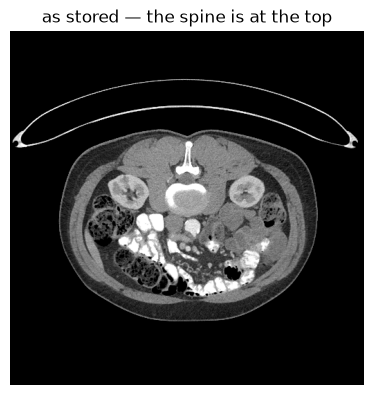

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.imshow(hu, cmap="gray", vmin=-160, vmax=240)
ax.set_title("as stored — the spine is at the top")
ax.axis("off")
plt.show()

The spine is at the top and the belly at the bottom. That is upside down.

The convention in medicine is that you view a cross-section **as if you were standing at the
patient's feet, looking up towards their head**. So the front of the body belongs at the top of the
picture, and the spine at the bottom.

Nothing is broken — the file simply says which way its rows and columns run, and we ignored it. The
header entry is called `ImageOrientationPatient`, and it holds six numbers.

In [8]:
orientation = [float(v) for v in ds.ImageOrientationPatient]

print("ImageOrientationPatient:", orientation)
print("  first three  (which way the columns run):", orientation[:3])
print("  second three (which way the rows run):   ", orientation[3:])

ImageOrientationPatient: [1.0, 0.0, 0.0, 0.0, -1.0, 0.0]
  first three  (which way the columns run): [1.0, 0.0, 0.0]
  second three (which way the rows run):    [0.0, -1.0, 0.0]


To read those six numbers you need the coordinate system they use, which is:

- **x** points to the patient's **left**
- **y** points to the patient's **back**
- **z** points up towards the patient's **head**

Each group of three says which of those directions you travel in as you move along the image.

A typical CT has rows running `[0, 1, 0]` — moving down the rows takes you towards the patient's
back. So the first row is the front of the body, and it gets drawn at the top. Correct.

This scan has rows running `[0, -1, 0]` — the opposite. Moving down the rows takes you towards the
*front*, so the first row is the back, and the spine gets drawn on top.

This matters more than it might seem. The upside-down picture still looks like a perfectly
reasonable abdomen, so nothing warns you. The same kind of mistake in the left–right direction
would swap a patient's left and right, and that has reached print in published papers. **Read the
six numbers. Never assume them.**

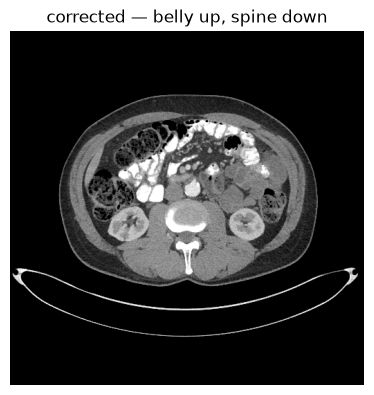

In [9]:
columns_run, rows_run = orientation[:3], orientation[3:]

if rows_run[1] < 0:        # rows run towards the front instead of the back
    hu = hu[::-1, :]       # flip top to bottom
if columns_run[0] < 0:     # columns run towards the right instead of the left
    hu = hu[:, ::-1]       # flip left to right

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.imshow(hu, cmap="gray", vmin=-160, vmax=240)
ax.set_title("corrected — belly up, spine down")
ax.axis("off")
plt.show()

`md.load_series`, used from here on, applies this correction for you. It also puts the slices in
head-to-foot order, so that side views come out the right way up as well.

## 4. Windowing: choosing what you can see

A CT scan covers about 4000 Hounsfield units, from air to dense bone. A screen shows only 256
shades of grey, and your eye tells apart fewer than that.

So if you spread the whole range across the screen, every soft tissue — fat, muscle, liver, kidney —
is squeezed into a couple of nearly identical greys, and you can see none of it.

The fix is called **windowing**: pick a narrow slice of the range and stretch just that across the
full black-to-white scale. Everything below becomes solid black, everything above solid white, and
the part you care about gets all the contrast.

A window is described by its **centre** (where it sits) and its **width** (how wide it is). In code
that is just `vmin` and `vmax`. The data never changes — only what you can see.

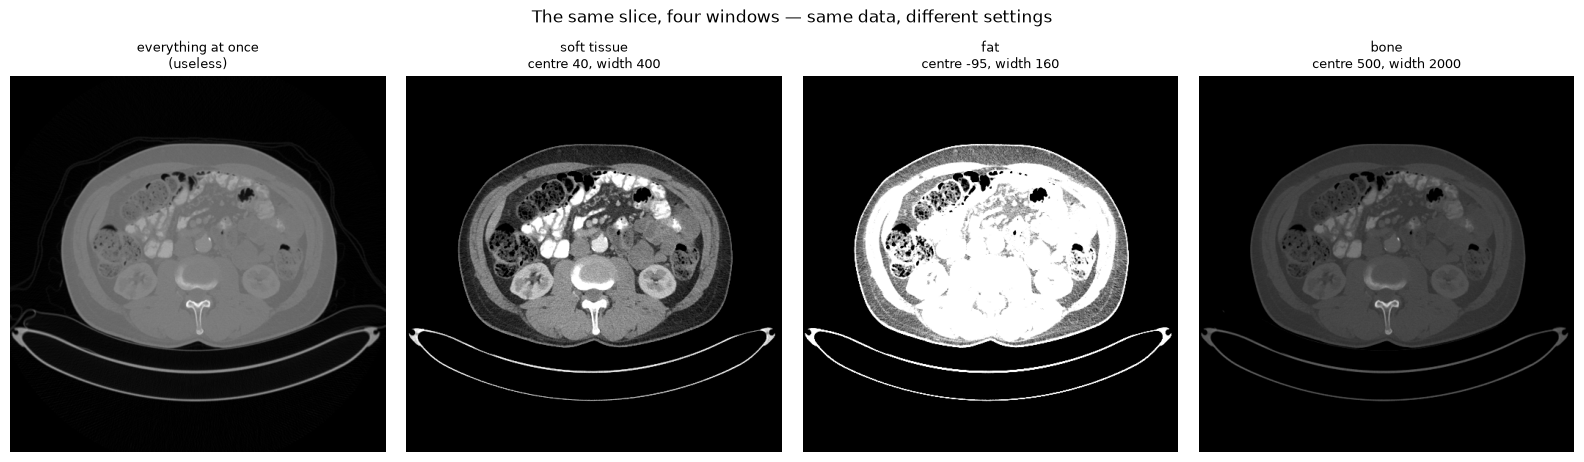

In [10]:
def window(center, width):
    """Convert a radiology-style window into (vmin, vmax) for imshow."""
    return center - width / 2, center + width / 2


views = {
    "everything at once\n(useless)": (hu.min(), hu.max()),
    "soft tissue\ncentre 40, width 400": window(40, 400),
    "fat\ncentre -95, width 160": window(-95, 160),
    "bone\ncentre 500, width 2000": window(500, 2000),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (title, (vmin, vmax)) in zip(axes, views.items()):
    ax.imshow(hu, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle("The same slice, four windows — same data, different settings", y=1.04)
plt.tight_layout()
plt.show()

The fat window is the interesting one for this course. It is set to the fat range from the table
above, so fat lights up and almost everything else goes white — which is, in visual form, exactly
the measurement Chapter 5 makes by counting.

## 5. From image to PyTorch tensor

Later chapters hand images to neural networks — including the one Chapter 5 uses to find organs.
Networks do not read DICOM files; they take **tensors**, which are essentially NumPy arrays that
can run on a GPU.

Three conventions catch people out:

1. **Shape.** PyTorch expects four dimensions: `(batch, channel, height, width)`. One slice is only
   `(height, width)`, so two dimensions have to be added.
2. **Number type.** Networks want decimals (`float32`); DICOM gives whole numbers.
3. **Range.** Values from −1000 to +3000 make training unstable. Squash them into roughly 0 to 1.

One detail is easy to get wrong. We squash using **fixed** HU limits, not each image's own minimum
and maximum. If you scaled every scan by its own range, the same tissue would end up as a different
number in different scans — throwing away the very thing that makes CT measurable.

In [11]:
import torch


def ct_to_tensor(hu_image, center=40.0, width=400.0):
    """Window a CT slice and return it as a (1, 1, H, W) float32 tensor."""
    lo, hi = window(center, width)
    scaled = (np.clip(hu_image, lo, hi) - lo) / (hi - lo)      # now between 0 and 1
    return torch.from_numpy(scaled.astype(np.float32))[None, None]


x = ct_to_tensor(hu)

print("PyTorch version:", torch.__version__)
print("tensor shape:   ", tuple(x.shape), " (batch, channel, height, width)")
print("number type:    ", x.dtype)
print("range:          ", round(float(x.min()), 2), "to", round(float(x.max()), 2))

PyTorch version: 2.13.0+cu130
tensor shape:    (1, 1, 512, 512)  (batch, channel, height, width)
number type:     torch.float32
range:           0.0 to 1.0


## 6. The third dimension

So far we have looked at one slice. A scan is a whole stack of them.

The idea is simple and worth saying out loud: a row of numbers is 1D, a grid of rows is 2D (one
slice), a stack of slices is 3D (the scan), and a series of scans over time would be 4D. Each time
you add a dimension you are stacking the previous thing.

By convention the new dimension goes first, so a scan is indexed `volume[slice, row, column]`.

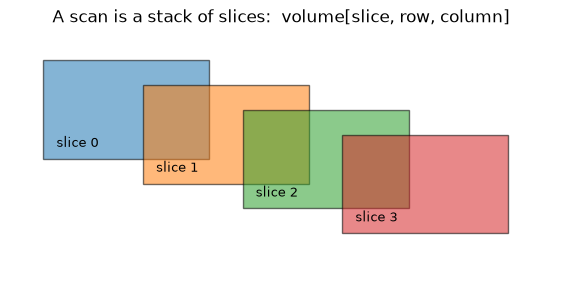

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for i, offset in enumerate([0, 0.9, 1.8, 2.7]):
    ax.add_patch(plt.Rectangle((offset, -offset * 0.28), 1.5, 1.0,
                               facecolor=f"C{i}", alpha=0.55, edgecolor="black"))
    ax.text(offset + 0.12, -offset * 0.28 + 0.12, f"slice {i}", fontsize=9)
ax.set_xlim(-0.3, 4.6)
ax.set_ylim(-1.2, 1.3)
ax.set_title("A scan is a stack of slices:  volume[slice, row, column]")
ax.axis("off")
plt.show()

### Loading the whole scan

You could read the files one by one and stack them, but there is a trap: file names do not
necessarily run in anatomical order. Stack them in the wrong order and the body gets scrambled,
quietly.

`load_series` reads the folder, sorts the slices by their real physical position, converts to
Hounsfield units, fixes the orientation, and works out the true spacing.

In [13]:
vol, spacing, datasets = md.load_series(ct_dir)
dz, dy, dx = spacing

print("scan shape:", vol.shape, " (slices, rows, columns)")
print(f"spacing:    {dz:.2f} mm between slices, {dy:.2f} x {dx:.2f} mm per pixel")
print("HU range:  ", vol.min(), "to", vol.max())

scan shape: (210, 512, 512)  (slices, rows, columns)
spacing:    1.00 mm between slices, 0.90 x 0.90 mm per pixel
HU range:   -1024 to 1373


### Size in pixels versus size in centimetres

Three ideas that are easy to mix up, and mixing them up makes every measurement wrong by a fixed
factor:

- **Shape** — how many pixels there are. Just a property of the array.
- **Spacing** — how many millimetres one pixel covers. Comes from the header.
- **Field of view** — the real size of the whole scan: shape × spacing.

Chapters 3 and 5 measure areas by counting pixels and multiplying by the area of one pixel. So
spacing is the bridge between "number of pixels" and "square centimetres".

In [14]:
n_slices, n_rows, n_cols = vol.shape

print(f"pixels     : {n_slices} x {n_rows} x {n_cols}")
print(f"real size  : {n_slices * dz:.0f} x {n_rows * dy:.0f} x {n_cols * dx:.0f} mm")
print(f"             ({n_slices * dz / 10:.1f} cm of the body from top to bottom)")
print()
print(f"one pixel covers {dy * dx:.4f} mm^2  =  {dy * dx / 100:.6f} cm^2")

pixels     : 210 x 512 x 512
real size  : 210 x 460 x 460 mm
             (21.0 cm of the body from top to bottom)

one pixel covers 0.8072 mm^2  =  0.008072 cm^2


That last number does the real work in Chapter 5. A muscle area in square centimetres is nothing
more than *the number of muscle pixels* × *the area of one pixel*.

## 7. Looking at a 3D scan

You cannot show a 3D object in one 2D picture, so you slice it and show several slices at once.

One practical note: when you make a grid of plots, draw on each panel directly
(`axes[i].imshow(...)`) rather than calling `plt.imshow(...)`, which has no way of knowing which
panel you meant.

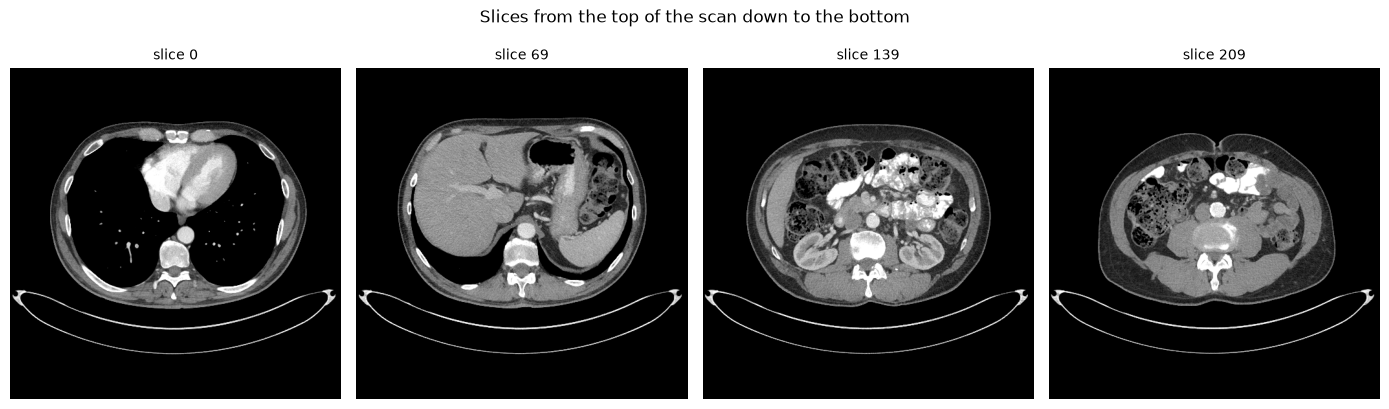

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, np.linspace(0, n_slices - 1, 4).astype(int)):
    ax.imshow(vol[idx], cmap="gray", vmin=-160, vmax=240)
    ax.set_title(f"slice {idx}", fontsize=10)
    ax.axis("off")
fig.suptitle("Slices from the top of the scan down to the bottom", y=1.02)
plt.tight_layout()
plt.show()

### The other two directions

Slicing the stack the way we just did gives cross-sections — the **axial** view. But a 3D array can
be cut along any axis. Cut it the other two ways and you get the view from the front (**coronal**)
and the view from the side (**sagittal**). Same data, different direction.

There is a catch. In this scan a pixel is about 0.9 mm across, but the slices are 1 mm apart, and in
many scans that gap is much bigger — 5 mm or more. In the front and side views one axis is
therefore spaced differently from the other, and the picture comes out stretched or squashed unless
you tell matplotlib the real proportions with `aspect`.

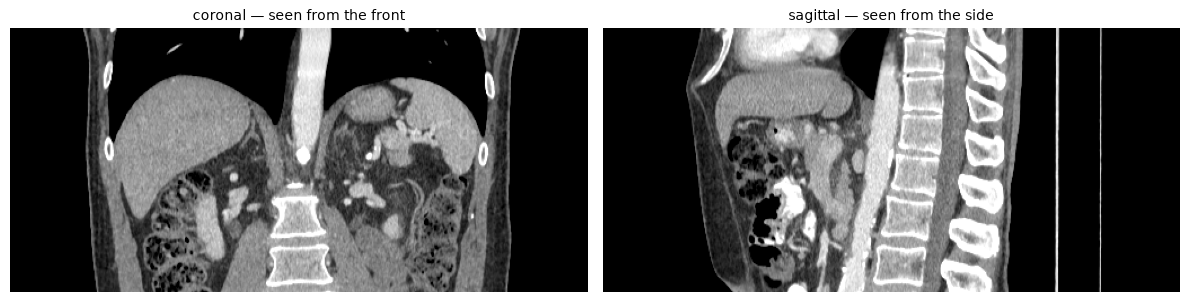

In [16]:
coronal = vol[:, n_rows // 2, :]
sagittal = vol[:, :, n_cols // 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(coronal, cmap="gray", vmin=-160, vmax=240, aspect=dz / dx)
axes[0].set_title("coronal — seen from the front", fontsize=10)
axes[1].imshow(sagittal, cmap="gray", vmin=-160, vmax=240, aspect=dz / dy)
axes[1].set_title("sagittal — seen from the side", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The side view is how Chapter 5 finds where to measure. Body composition is measured at one standard
place — the level of the third lumbar vertebra, partway down the spine — and this is the view in
which you can count vertebrae to find it.

## Exercises

1. Run `md.fetch_pancreas_ct(1)` to fetch a second patient. Compare the pixel spacing and the field
   of view with the first. If you measured something in pixels, would the two patients be
   comparable? What if you measured in square centimetres?
2. Work out the tissue percentages for the very first and very last slice of `vol`. Why is there so
   much more lung in one of them?
3. Take the correction in section 3 back out and plot the coronal view without it. What changes,
   and would you have noticed if nobody had told you?
4. Skip the Hounsfield conversion on purpose: calculate the "fat percentage" straight from
   `ds.pixel_array`. How wrong is the answer, and why is it wrong by so much?

## References

- [pydicom documentation](https://pydicom.github.io/pydicom/stable/)
- [The Cancer Imaging Archive](https://www.cancerimagingarchive.net/)
- [PyTorch documentation](https://pytorch.org/docs/stable/index.html)
- Hounsfield GN. *Computed medical imaging.* Science. 1980;210(4465):22–28.
- Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). *Data From Pancreas-CT.*
  The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2016.tNB1kqBU](https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU)